In [2]:
# ============================================
# Breast Cancer Wisconsin — Teaching Project
# Structure follows Unsupervised + Classification curricula
# ============================================

# ---------- PART 1: Libraries ----------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    silhouette_score, adjusted_rand_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

RANDOM_STATE = 42
print('Libraries loaded.')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries loaded.


In [3]:
# ---------- 1.2 Load ----------
df = pd.read_csv('data.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()
df.describe().T.round(2)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,count,mean,std,min,25%,50%,75%,max
id,569.0,30371831.43,1.250206e+08,8670.00,869218.00,906024.00,8813129.00,9.113205e+08
radius_mean,569.0,14.13,3.520000e+00,6.98,11.70,13.37,15.78,2.811000e+01
texture_mean,569.0,19.29,4.300000e+00,9.71,16.17,18.84,21.80,3.928000e+01
perimeter_mean,569.0,91.97,2.430000e+01,43.79,75.17,86.24,104.10,1.885000e+02
area_mean,569.0,654.89,3.519100e+02,143.50,420.30,551.10,782.70,2.501000e+03
smoothness_mean,569.0,0.10,1.000000e-02,0.05,0.09,0.10,0.11,1.600000e-01
compactness_mean,569.0,0.10,5.000000e-02,0.02,0.06,0.09,0.13,3.500000e-01
concavity_mean,569.0,0.09,8.000000e-02,0.00,0.03,0.06,0.13,4.300000e-01
concave points_mean,569.0,0.05,4.000000e-02,0.00,0.02,0.03,0.07,2.000000e-01
symmetry_mean,569.0,0.18,3.000000e-02,0.11,0.16,0.18,0.20,3.000000e-01


In [5]:
# ---------- 1.3 Cleaning (basic) ----------
df_clean = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])  # B=0, M=1

print('Class counts:')
print(df_clean['diagnosis'].value_counts())
print(f'\nClass balance: {df_clean["diagnosis"].mean():.1%} malignant')

X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']
print(f'\nFeatures shape: {X.shape}')

Class counts:
diagnosis
0    357
1    212
Name: count, dtype: int64

Class balance: 37.3% malignant

Features shape: (569, 30)


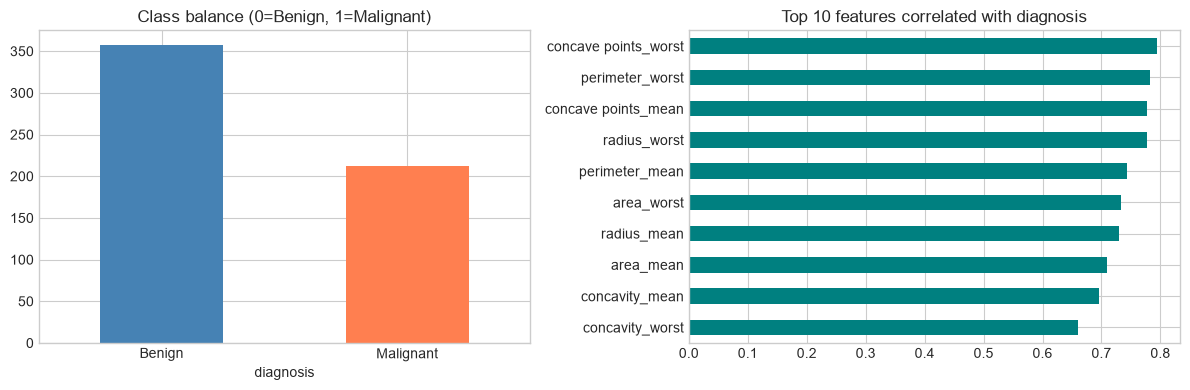

In [6]:
# ---------- 1.4 Quick EDA ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Class balance (0=Benign, 1=Malignant)')
axes[0].set_xticklabels(['Benign', 'Malignant'], rotation=0)

corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
corr_with_target.head(10).plot(kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Top 10 features correlated with diagnosis')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

10 components explain ≥ 95% of the variance.


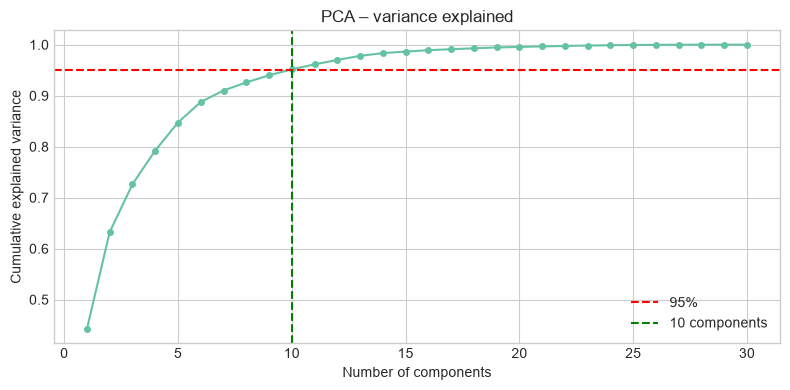

X_pca shape: (569, 10)


In [7]:
# ---------- 1.5 Scaling + PCA (simplification) ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumsum >= 0.95) + 1
print(f'{n_95} components explain ≥ 95% of the variance.')

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumsum)+1), cumsum, marker='o', markersize=4)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.axvline(n_95, color='green', linestyle='--', label=f'{n_95} components')
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA – variance explained')
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=n_95, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f'X_pca shape: {X_pca.shape}')

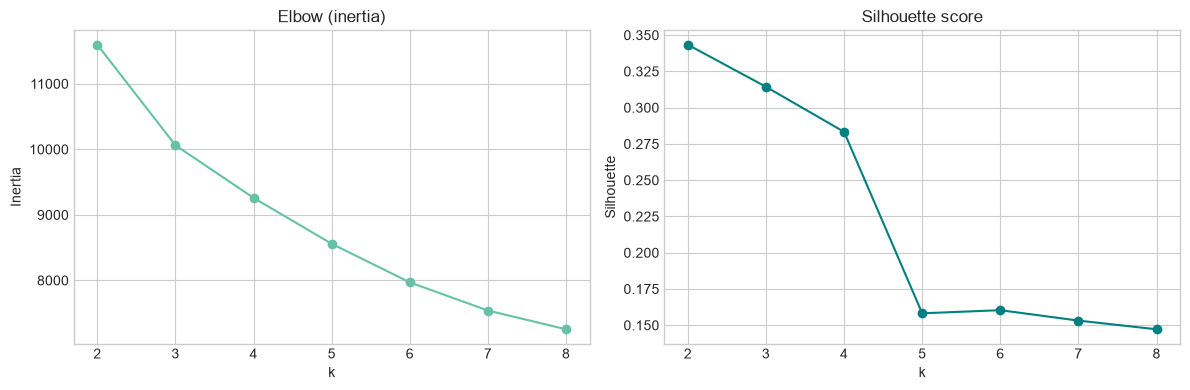

Silhouette scores:
  k=2: 0.343
  k=3: 0.314
  k=4: 0.283
  k=5: 0.158
  k=6: 0.160
  k=7: 0.153
  k=8: 0.147


In [8]:
# ============================================
# PART 2 — Clustering + 3 tests
# ============================================

# 2.1 Choosing k
ks = range(2, 9)
inertias, silhouettes = [], []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o')
axes[0].set_title('Elbow (inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(ks, silhouettes, marker='o', color='teal')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
plt.tight_layout()
plt.show()

print('Silhouette scores:')
for k, s in zip(ks, silhouettes):
    print(f'  k={k}: {s:.3f}')

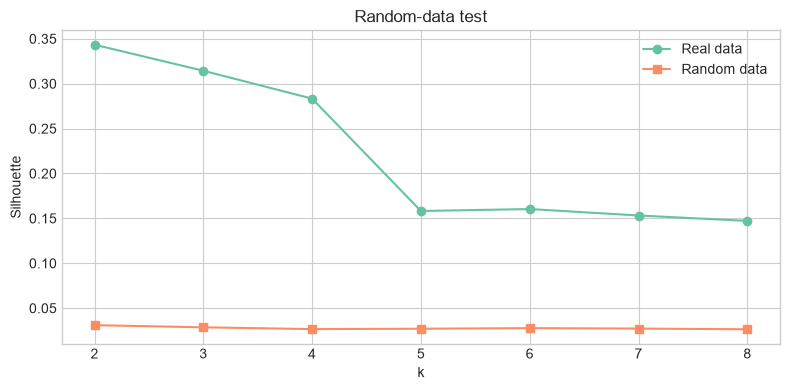

Real vs Random silhouette (k=2):
  Real   : 0.343
  Random : 0.031


In [9]:
# 2.2 Random-data test
rng = np.random.default_rng(RANDOM_STATE)
X_random = rng.normal(size=X_scaled.shape)

sil_real, sil_rand = [], []
for k in ks:
    sil_real.append(silhouette_score(X_scaled, KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)))
    sil_rand.append(silhouette_score(X_random, KMeans(k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_random)))

plt.figure(figsize=(8, 4))
plt.plot(ks, sil_real, marker='o', label='Real data')
plt.plot(ks, sil_rand, marker='s', label='Random data')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.title('Random-data test')
plt.legend()
plt.tight_layout()
plt.show()

print('Real vs Random silhouette (k=2):')
print(f'  Real   : {sil_real[0]:.3f}')
print(f'  Random : {sil_rand[0]:.3f}')

In [10]:
# 2.3 Final clustering + naming
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

profile = X.copy()
profile['cluster'] = cluster_labels
means = profile.groupby('cluster').mean().T
means.columns = ['Cluster 0', 'Cluster 1']
print('Cluster profiles (selected features):')
print(means.loc[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                 'concave points_mean', 'radius_worst', 'area_worst']].round(2))

Cluster profiles (selected features):
                     Cluster 0  Cluster 1
radius_mean              12.43      17.41
texture_mean             18.26      21.28
perimeter_mean           79.82     115.45
area_mean               486.77     979.86
concave points_mean       0.03       0.09
radius_worst             13.77      21.10
area_worst              596.52    1429.67


In [11]:
# 2.4 Held-back label
ari = adjusted_rand_score(y, cluster_labels)
sil = silhouette_score(X_scaled, cluster_labels)
print(f'Adjusted Rand Index vs true diagnosis: {ari:.4f}')
print(f'Silhouette score:                     {sil:.4f}')

ct = pd.crosstab(pd.Series(y, name='diagnosis'),
                 pd.Series(cluster_labels, name='cluster'),
                 normalize='index')
print('\nHow pure are the clusters? (row-normalized)')
print(ct.round(3))

Adjusted Rand Index vs true diagnosis: 0.6536
Silhouette score:                     0.3434

How pure are the clusters? (row-normalized)
cluster       0     1
diagnosis            
0          0.95  0.05
1          0.17  0.83


Stability (ARI across 20 seeds): mean=0.981, min=0.965


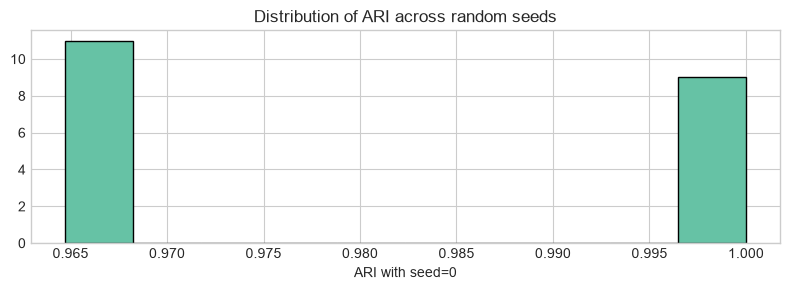

In [12]:
# 2.5 Stability
base_labels = KMeans(2, random_state=0, n_init=10).fit_predict(X_scaled)
aris = []
for seed in range(1, 21):
    labels = KMeans(2, random_state=seed, n_init=10).fit_predict(X_scaled)
    aris.append(adjusted_rand_score(base_labels, labels))

print(f'Stability (ARI across 20 seeds): mean={np.mean(aris):.3f}, min={np.min(aris):.3f}')
plt.figure(figsize=(8, 3))
plt.hist(aris, bins=10, edgecolor='black')
plt.title('Distribution of ARI across random seeds')
plt.xlabel('ARI with seed=0')
plt.tight_layout()
plt.show()

In [13]:
# 2.6 Hierarchical + DBSCAN (quick comparison)
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_scaled)
print(f'Agglomerative ARI vs diagnosis: {adjusted_rand_score(y, agg_labels):.4f}')

for eps in [1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_scaled)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = list(db_labels).count(-1)
    print(f'DBSCAN eps={eps}: {n_clusters} clusters, {n_noise} noise points')

Agglomerative ARI vs diagnosis: 0.5750
DBSCAN eps=1.0: 0 clusters, 569 noise points
DBSCAN eps=1.5: 1 clusters, 550 noise points
DBSCAN eps=2.0: 4 clusters, 371 noise points


In [31]:
# ============================================
# PART 3 — Supervised
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} ({y_train.mean():.1%} malignant)')
print(f'Test : {X_test.shape[0]} ({y_test.mean():.1%} malignant)')

Train: 455 (37.4% malignant)
Test : 114 (36.8% malignant)


In [32]:
# Baseline
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
print(f'Dummy accuracy: {dummy.score(X_test, y_test):.3f}')

Dummy accuracy: 0.632


In [33]:
# All curriculum models
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
    }
    if y_proba is not None:
        row['ROC-AUC'] = roc_auc_score(y_test, y_proba)
    results.append(row)
    trained[name] = model

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df.round(4).to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
          SVM (RBF)    0.9737     1.0000  0.9286 0.9630   0.9954
      Random Forest    0.9737     1.0000  0.9286 0.9630   0.9929
Logistic Regression    0.9649     0.9750  0.9286 0.9512   0.9960
  Gradient Boosting    0.9649     1.0000  0.9048 0.9500   0.9947
                KNN    0.9561     0.9744  0.9048 0.9383   0.9816
      Decision Tree    0.9298     0.9048  0.9048 0.9048   0.9246
        Naive Bayes    0.9211     0.9231  0.8571 0.8889   0.9891


In [34]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    print(f'{name:22s}  CV accuracy = {scores.mean():.4f} ± {scores.std():.4f}')

KNN                     CV accuracy = 0.9666 ± 0.0140
Logistic Regression     CV accuracy = 0.9737 ± 0.0166
Naive Bayes             CV accuracy = 0.9297 ± 0.0199
Decision Tree           CV accuracy = 0.9104 ± 0.0279
SVM (RBF)               CV accuracy = 0.9754 ± 0.0195
Random Forest           CV accuracy = 0.9543 ± 0.0128
Gradient Boosting       CV accuracy = 0.9508 ± 0.0245


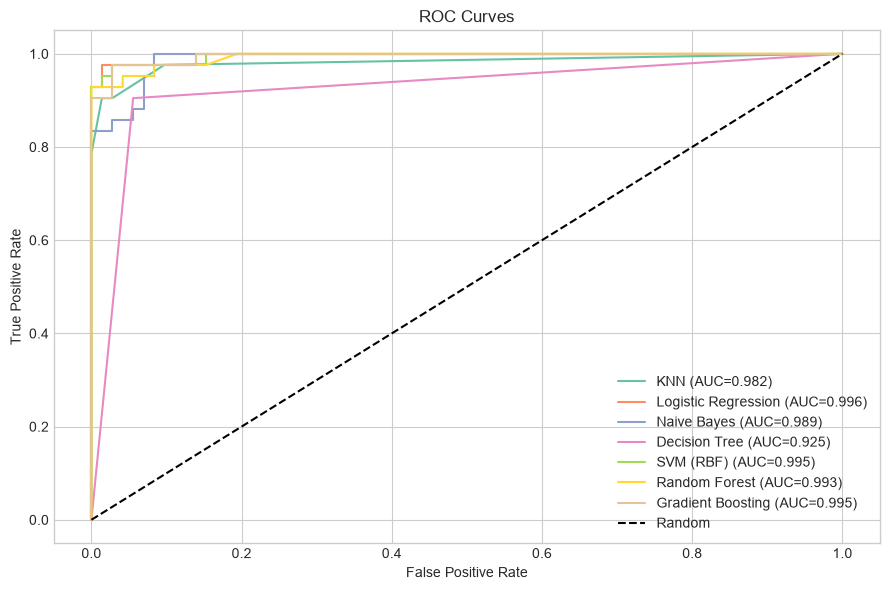

In [35]:
# ROC curves
plt.figure(figsize=(9, 6))
for name, model in trained.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [36]:
# Tuning the top models
param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        'params': {'C': [0.01, 0.1, 1, 10, 100]}
    },
    'SVM (RBF)': {
        'model': SVC(probability=True, random_state=RANDOM_STATE),
        'params': {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1]}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators': [100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5]}
    },
}

tuned_results = []
best_models = {}

for name, cfg in param_grids.items():
    print(f'Tuning {name} ...')
    grid = GridSearchCV(
        cfg['model'], cfg['params'],
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        scoring='f1', n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1]
    
    tuned_results.append({
        'Model': name + ' (Tuned)',
        'Best Params': str(grid.best_params_),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    best_models[name] = best
    print(f'  Best params: {grid.best_params_}')
    print(f'  Test F1    : {f1_score(y_test, y_pred):.4f}\n')

tuned_df = pd.DataFrame(tuned_results).sort_values('Accuracy', ascending=False)
print('=== Tuned ranking ===')
print(tuned_df[['Model', 'Accuracy', 'F1', 'ROC-AUC']].round(4).to_string(index=False))

Tuning Logistic Regression ...
  Best params: {'C': 1}
  Test F1    : 0.9512

Tuning SVM (RBF) ...
  Best params: {'C': 10, 'gamma': 0.01}
  Test F1    : 0.9756

Tuning Random Forest ...
  Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  Test F1    : 0.9630

Tuning Gradient Boosting ...
  Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
  Test F1    : 0.9500

=== Tuned ranking ===
                      Model  Accuracy     F1  ROC-AUC
          SVM (RBF) (Tuned)    0.9825 0.9756   0.9960
      Random Forest (Tuned)    0.9737 0.9630   0.9929
Logistic Regression (Tuned)    0.9649 0.9512   0.9960
  Gradient Boosting (Tuned)    0.9649 0.9500   0.9954


=== FINAL BEST MODEL: SVM (RBF) ===
Model                 SVM (RBF) (Tuned)
Best Params    {'C': 10, 'gamma': 0.01}
Accuracy                       0.982456
Precision                           1.0
Recall                         0.952381
F1                              0.97561
ROC-AUC                        0.996032
Name: 1, dtype: object

Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      1.00      0.99        72
   Malignant       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



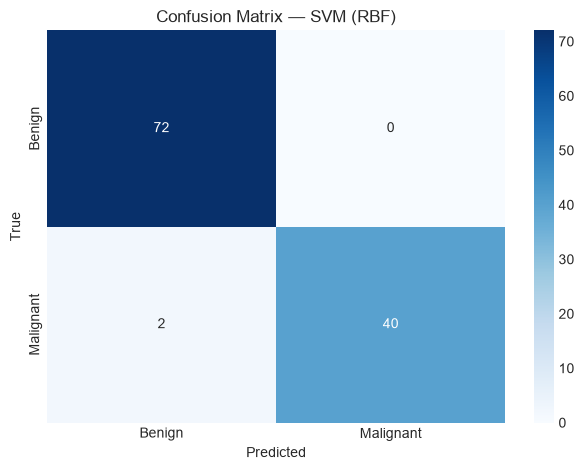

In [37]:
# Final best model detailed evaluation
final_name = tuned_df.iloc[0]['Model'].replace(' (Tuned)', '')
final_model = best_models[final_name]

print(f'=== FINAL BEST MODEL: {final_name} ===')
print(tuned_df.iloc[0])

y_pred = final_model.predict(X_test)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Confusion Matrix — {final_name}')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [38]:
# Feature importance / coefficients
if hasattr(final_model, 'feature_importances_'):
    imp = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(9, 6))
    imp.head(12).plot(kind='barh', color='teal')
    plt.gca().invert_yaxis()
    plt.title(f'Top feature importances — {final_name}')
    plt.tight_layout()
    plt.show()
    print(imp.head(10))
elif hasattr(final_model, 'coef_'):
    coef = pd.Series(np.abs(final_model.coef_[0]), index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(9, 6))
    coef.head(12).plot(kind='barh', color='teal')
    plt.gca().invert_yaxis()
    plt.title(f'Top |coefficients| — {final_name}')
    plt.tight_layout()
    plt.show()
    print(coef.head(10))
else:
    print('This model does not expose feature importances or coefficients directly.')

This model does not expose feature importances or coefficients directly.


In [39]:
# ========== SUMMARY ==========
print('='*60)
print('BREAST CANCER PROJECT — SUMMARY')
print('='*60)
print(f'Dataset          : Breast Cancer Wisconsin Diagnostic')
print(f'Samples          : {len(df_clean)} | Features: {X.shape[1]}')
print(f'Classes          : Benign={sum(y==0)}, Malignant={sum(y==1)}')
print()
print('PART 1 — Preprocessing')
print('  Dropped id & empty column, encoded diagnosis (B=0, M=1)')
print(f'  PCA: {n_95} components explain ≥95% variance')
print()
print('PART 2 — Clustering (KMeans k=2)')
print(f'  Adjusted Rand Index vs diagnosis : {ari:.4f}')
print(f'  Silhouette score                 : {sil:.4f}')
print(f'  Stability (mean ARI across seeds): {np.mean(aris):.3f}')
print()
print('PART 3 — Supervised')
print(f'  Best model : {final_name}')
print(f'  Accuracy   : {tuned_df.iloc[0]["Accuracy"]:.4f}')
print(f'  Precision  : {tuned_df.iloc[0]["Precision"]:.4f}')
print(f'  Recall     : {tuned_df.iloc[0]["Recall"]:.4f}')
print(f'  F1-Score   : {tuned_df.iloc[0]["F1"]:.4f}')
print(f'  ROC-AUC    : {tuned_df.iloc[0]["ROC-AUC"]:.4f}')
print('='*60)

BREAST CANCER PROJECT — SUMMARY
Dataset          : Breast Cancer Wisconsin Diagnostic
Samples          : 569 | Features: 30
Classes          : Benign=357, Malignant=212

PART 1 — Preprocessing
  Dropped id & empty column, encoded diagnosis (B=0, M=1)
  PCA: 10 components explain ≥95% variance

PART 2 — Clustering (KMeans k=2)
  Adjusted Rand Index vs diagnosis : 0.6536
  Silhouette score                 : 0.3434
  Stability (mean ARI across seeds): 0.981

PART 3 — Supervised
  Best model : SVM (RBF)
  Accuracy   : 0.9825
  Precision  : 1.0000
  Recall     : 0.9524
  F1-Score   : 0.9756
  ROC-AUC    : 0.9960
